### Test for estimating Adria Euler pole w.r.t. Eurasia

In [102]:
using CSV,DataFrames,GMT

include("../src/GeoUtils.jl");
import .GeoUtils as GU

In [103]:
DataSet=CSV.read("./combined.cmm4",DataFrame,delim=' ', ignorerepeated=true, header=["Site", "Long", "Lat", "E_Rate", "σ_E", "N_Rate", "σ_N", "Ren"])
statList1=CSV.read("adria.list", skipto=1, delim=' ', ignorerepeated=true, DataFrame, header=["Name"])

indices, list_of_found_stat=GU.GetByName(DataSet,statList1[:,1])

AdriaPlate=DataSet[indices,:]
AdriaPlateMatrix=Matrix{Float64}(AdriaPlate[:,[2,3,4,6,5,7]])

55×6 Matrix{Float64}:
  8.2032  44.9057   0.25   0.28  0.13  0.12
 13.0694  45.6719  -0.24   2.17  0.09  0.1
  9.3834  44.7706   0.57   0.74  0.13  0.14
 11.2842  45.4007   0.05   1.15  0.13  0.17
 11.9392  45.6703  -0.02   1.46  0.11  0.1
  8.2805  44.4053   0.64  -0.1   0.12  0.11
  8.2928  44.7223   0.41   0.06  0.09  0.12
 10.4265  45.3682   0.06   0.88  0.12  0.13
  9.119   45.7432   0.04   0.18  0.12  0.14
 10.841   45.5246   0.14   1.06  0.14  0.19
  ⋮                                    ⋮
 10.828   45.4454  -0.07   1.11  0.17  0.16
 12.2085  45.857   -0.17   1.65  0.12  0.14
 12.3961  46.0605   0.05   1.27  0.16  0.2
 11.6773  45.3428   0.1    1.56  0.08  0.08
 12.2283  45.0031   0.16   1.85  0.1   0.12
 12.2432  45.6532  -0.26   2.05  0.12  0.12
 13.7635  45.7098  -0.3    2.4   0.13  0.09
 11.5563  45.5641  -0.01   1.33  0.08  0.1
 11.9109  45.3846   0.08   1.84  0.13  0.13

In [105]:
GU.estimate_euler_pole(AdriaPlateMatrix); #just to see the printed message
omega, cov, chisq, resE, resN= GU.estimate_euler_velocity(AdriaPlateMatrix);

Euler Pole: 
 lon: 8.138569224229972 pm 0.08008737216249147 
 lat: 45.39531870224225 pm 0.026312975434713344 
 rotation velocity: 0.3022446641849468 pm 0.006624160082045806 deg/Myr 



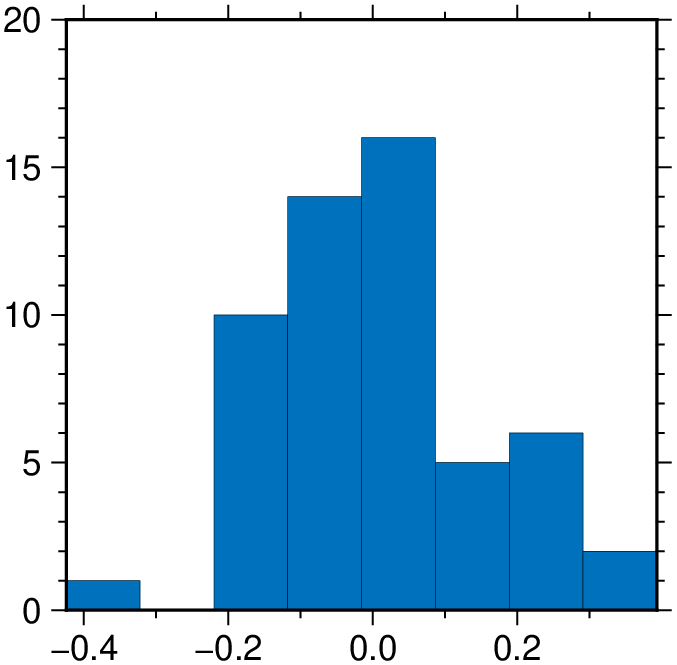

In [106]:
GMT.histogram(resE,region=[minimum(resE),maximum(resE),0,20],J="X5c",show=true)

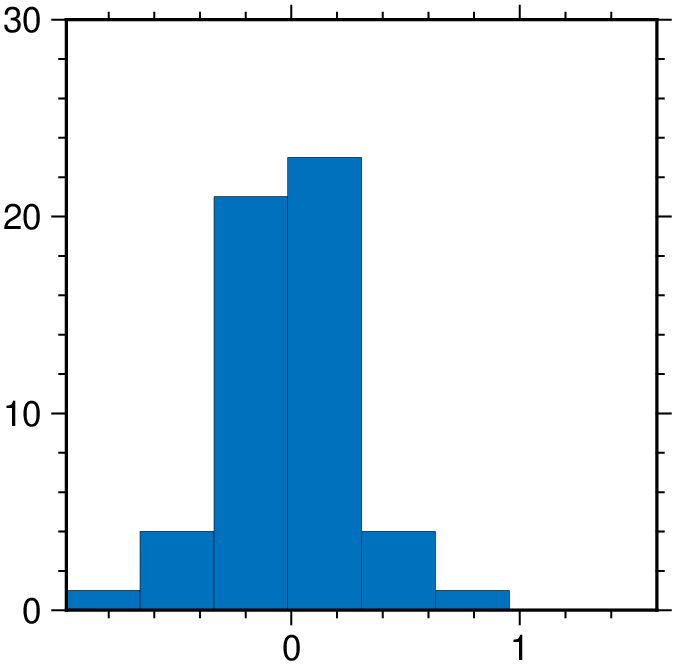

In [107]:
GMT.histogram(resN,region=[minimum(resN),maximum(resN),0,30],J="X5c",show=true)

In [108]:
omega

3-element Vector{Float64}:
 0.21010204301849675
 0.030046259650284648
 0.21518873304323496

In [109]:
omegamagn=sqrt(omega[1]^2 + omega[2]^2 + omega[3]^2)

0.3022446641849467

In [110]:
sqrt_cov=sqrt.(cov)

3×3 Matrix{Float64}:
 0.00456674  0.00203771   0.00464078
 0.00203771  0.000922447  0.00207191
 0.00464078  0.00207191   0.00472025

In [111]:
sqrt(sqrt_cov[1]^2+sqrt_cov[2]^2+sqrt_cov[3]^2)

0.006822329913213811

In [112]:
chisq

264.36835037562105

In [114]:
cov

3×3 Matrix{Float64}:
 2.08551e-5  4.15226e-6  2.15368e-5
 4.15226e-6  8.50909e-7  4.2928e-6
 2.15368e-5  4.2928e-6   2.22808e-5

In [115]:
New_E=[]
New_N=[]

#omega_lon_deg, omega_lat_deg, magn_deg_Myr, covariance_result_deg = GU.euler_pole_from_rotation(omega; cov_omega=cov) 
for i=1:size(AdriaPlateMatrix,1)

    New_ETemp,New_NTemp,_=GU.euler_velocity(AdriaPlateMatrix[i,1], AdriaPlateMatrix[i,2], omega, cov_input=cov)

    push!(New_E, New_ETemp)
    push!(New_N, New_NTemp)
end


In [116]:
maximum(abs.((AdriaPlateMatrix[:,3]-New_E) .- resE))

0.0

In [117]:
maximum(abs.((AdriaPlateMatrix[:,4]-New_N) .- resN))

0.0

In [118]:
rot_velE=[]
rot_velN=[]

for i=1:size(DataSet,1)

    rot_ETemp,rot_NTemp,_=GU.euler_velocity(DataSet[i,2], DataSet[i,3], omega, cov_input=cov)

    push!(rot_velE, DataSet[i,4]-rot_ETemp)
    push!(rot_velN, DataSet[i,6]-rot_NTemp)
end


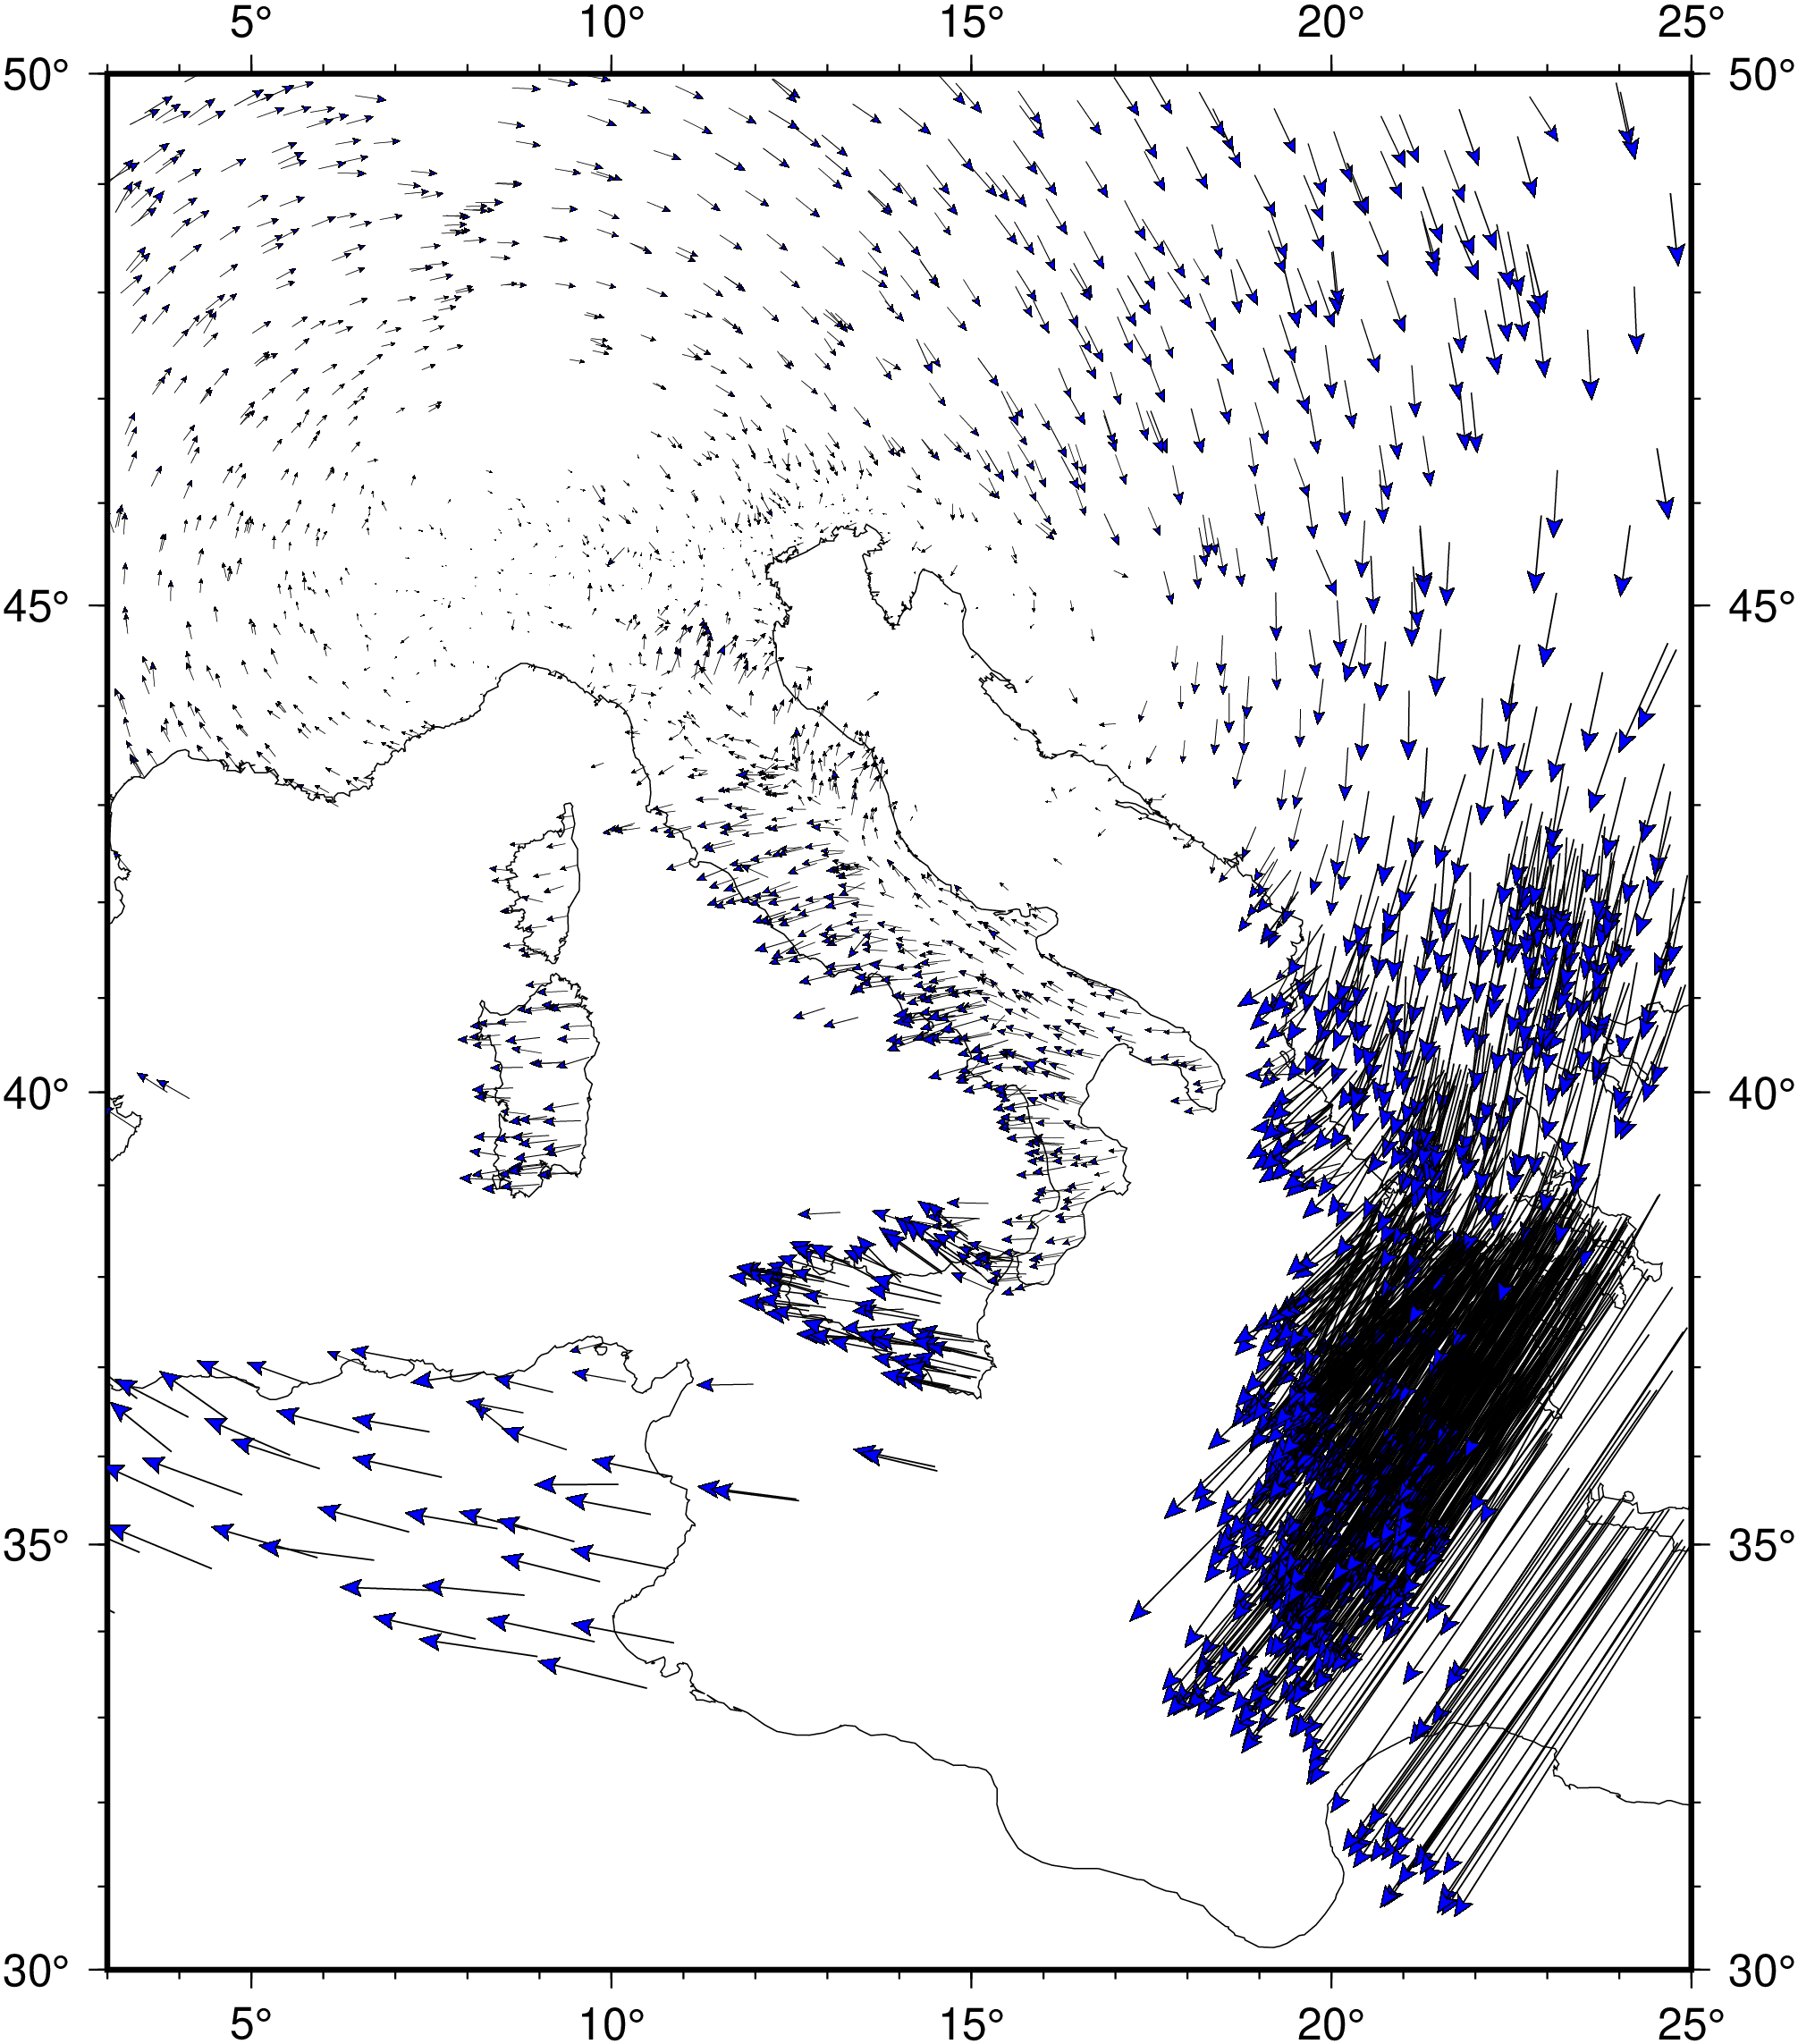

In [125]:
GU.plot_vector_map_S([3,25.0,30,50],0.1,Matrix{Float64}([DataSet[:,2] DataSet[:,3] rot_velE rot_velN]))
GMT.plot!(x=[NaN],y=[NaN],show=true)